In [ ]:
import numpy as np
import sys
sys.path.append('..')

# 🧠 DỰ ÁN PHÂN TÍCH VÀ DỰ ĐOÁN NGUY CƠ ĐỘT QUỴ
*(Stroke Prediction Analysis Project)*

---

### 📝 Giới thiệu chung
Notebook này hướng dẫn chi tiết toàn bộ quy trình từ **làm sạch dữ liệu (Data Cleaning)**, **phân tích khám phá dữ liệu (EDA)**, đến các bước **kỹ nghệ đặc trưng dựa trên nền tảng toán học (Mathematical Feature Engineering)** dành cho tập dữ liệu Dự đoán Đột quỵ (*Stroke Prediction Dataset*). 

Mục tiêu cốt lõi của dự án nhằm trích xuất các thông tin chuyên sâu (Insights) từ các chỉ số nhân khẩu học, sức khỏe và lối sống, từ đó xây dựng nền tảng toán học vững chắc cho đường ống AI (AI Pipeline) dự đoán nguy cơ đột quỵ của bệnh nhân.

### 🛠️ Các thư viện sử dụng trong Notebook:
* **NumPy:** Xử lý mảng đa chiều, tối ưu hóa tính toán tuyến tính và đại số từ đầu (Scratch).
* **Pandas:** Thao tác, làm sạch, gom nhóm và biến đổi cấu trúc dữ liệu DataFrame.
* **Matplotlib / Seaborn:** Trực quan hóa biểu đồ phân phối, ma trận tương quan và các chỉ số thống kê.

---

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

filepath = '../data/raw/healthcare-dataset-stroke-data.csv'
df = pd.read_csv(filepath)
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [ ]:
from src.numpy_tasks import *
filepath = '../data/raw/healthcare-dataset-stroke-data.csv'
matrix_data = q1_load_and_clean_data(filepath)


--- Q1: Data Loading & Cleaning ---
Shape: (5110, 3)
Dtype: float64



# Module 1: Numpy

--- Q2: Basic Statistics ---
Age -> Mean: 43.23, Median: 45.00, Std: 22.61
Avg_Glucose_Level -> Mean: 106.15, Median: 91.88, Std: 45.28
BMI -> Mean: 28.89, Median: 28.40, Std: 7.70



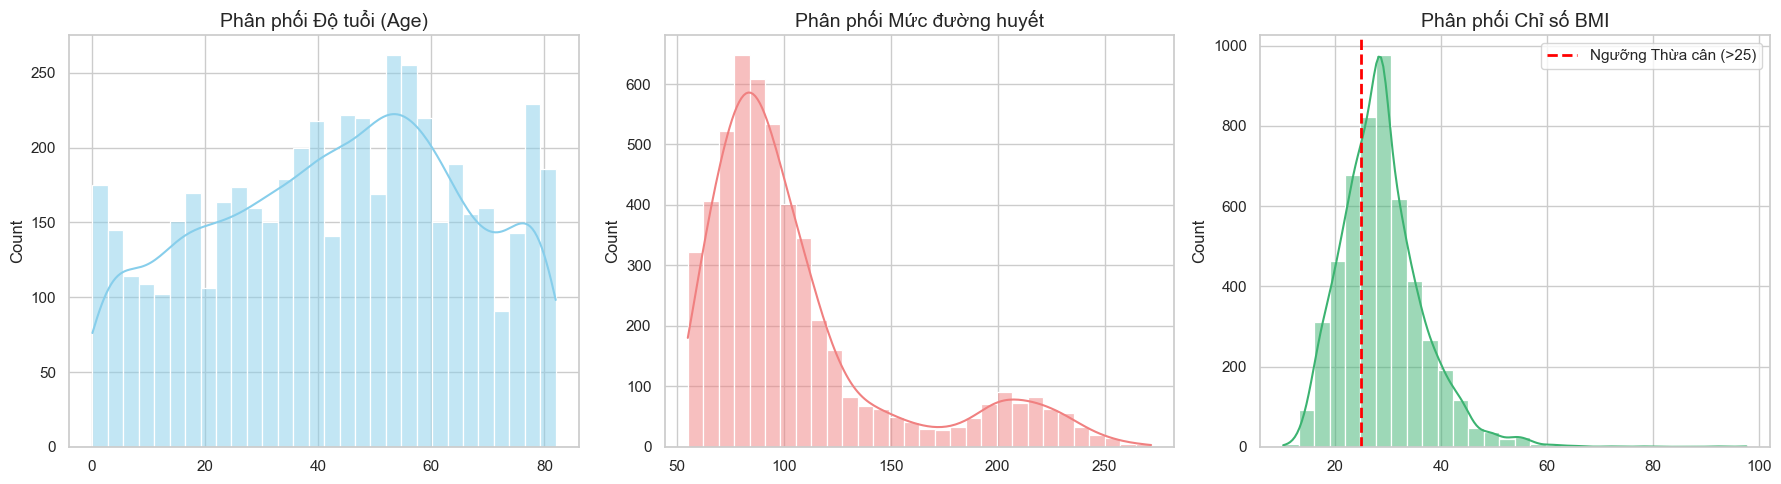

In [ ]:
q2_compute_statistics(matrix_data)
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(matrix_data[:, 0], bins=30, kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Phân phối Độ tuổi (Age)', fontsize=14)

sns.histplot(matrix_data[:, 1], bins=30, kde=True, color='lightcoral', ax=axes[1])
axes[1].set_title('Phân phối Mức đường huyết', fontsize=14)

sns.histplot(matrix_data[:, 2], bins=30, kde=True, color='mediumseagreen', ax=axes[2])
axes[2].axvline(25, color='red', linestyle='--', linewidth=2, label='Ngưỡng Thừa cân (>25)')
axes[2].set_title('Phân phối Chỉ số BMI', fontsize=14)
axes[2].legend()

plt.tight_layout()
plt.show()

--- Q5: Correlation Matrix ---
[[1.         0.23817111 0.32594247]
 [0.23817111 1.         0.16875135]
 [0.32594247 0.16875135 1.        ]] 



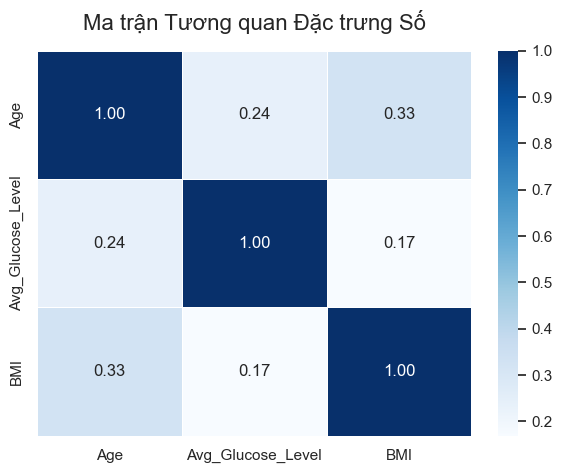

In [ ]:
# In kết quả ma trận số
q5_correlation_matrix(matrix_data)
corr_matrix = np.corrcoef(matrix_data, rowvar=False)

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt=".2f", linewidths=.5,
            xticklabels=['Age', 'Avg_Glucose_Level', 'BMI'], 
            yticklabels=['Age', 'Avg_Glucose_Level', 'BMI'])
plt.title('Ma trận Tương quan Đặc trưng Số', fontsize=16, pad=15)
plt.show()

--- Q9: Manual PCA ---
Projected Data Shape: (5110, 2)
First 2 projected records:
 [[ 2.61982949 -1.54379378]
 [ 1.56766683 -1.62711011]] 



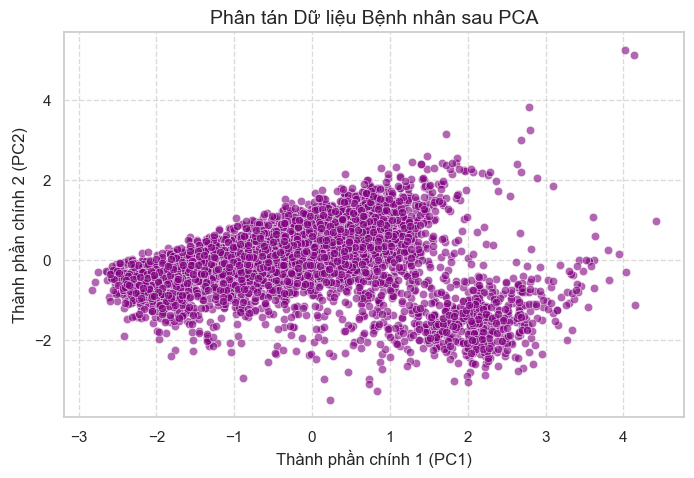

In [ ]:
# 1. Chạy hàm PCA và in kết quả chữ
pca_result = q9_manual_pca(matrix_data)

# 2. Vẽ biểu đồ phân tán
plt.figure(figsize=(8, 5))
x_pca = pca_result[:, 0]
y_pca = pca_result[:, 1]

sns.scatterplot(x=x_pca, y=y_pca, alpha=0.6, color='purple')
plt.title('Phân tán Dữ liệu Bệnh nhân sau PCA', fontsize=14)
plt.xlabel('Thành phần chính 1 (PC1)')
plt.ylabel('Thành phần chính 2 (PC2)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Module 2: Math

In [ ]:
from src.math_tasks import *
filepath = '../data/raw/healthcare-dataset-stroke-data.csv'
df_math = load_data(filepath)

--- Q1: Matrix Representation ---
Matrix Shape: (5110, 3)
Matrix Rank: 3

--- Q2: Linear Regression (Normal Equation) ---
Weights (b, w1, w2): [-0.0839252   0.00215857  0.00037067]

--- Q3: Base and Conditional Probabilities ---
P(stroke=1): 0.0487
P(stroke=1 | hypertension=1): 0.1325

--- Q5: Variance and Covariance ---
Variance of avg_glucose_level: 2050.20
Covariance between glucose and age: 243.88

--- Q9: Bayes' Theorem with Discretization ---
P(stroke | glucose_bin):
glucose_bin
Normal         0.035771
Prediabetic    0.037794
Diabetic       0.100000
Name: stroke, dtype: float64 

--- Q4: Compute Gradient of MSE ---
Gradient with respect to W: [ 1.13194950e-16  1.17983466e-15 -5.81504838e-15]

--- Q6: Covariance Matrix & Eigen Decomposition ---
Covariance Matrix:
 [[1.00019573 0.23821773 0.32600627]
 [0.23821773 1.00019573 0.16878438]
 [0.32600627 0.16878438 1.00019573]]
Eigenvalues:
 [1.49469606 0.66284554 0.8430456 ]
Eigenvectors:
 [[ 0.6313054   0.75442772  0.17970061]
 [ 0.505

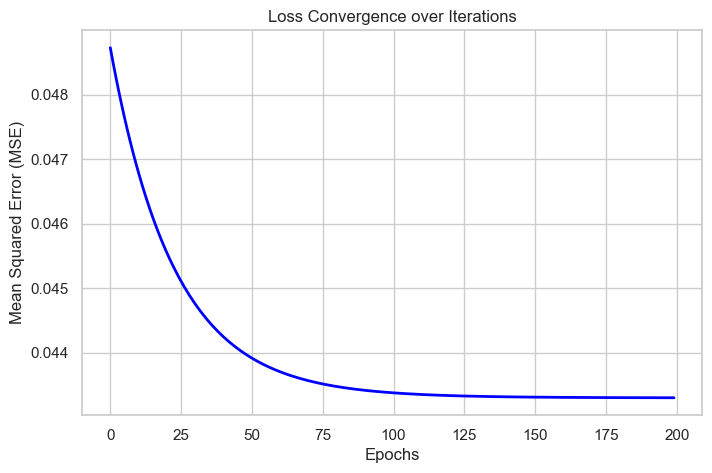

In [ ]:
X_num = q1_matrix_representation(df_math)
X_b, y, w_optimal = q2_linear_regression(df_math)
q3_probabilities(df_math)
q5_variance_covariance(df_math)
q9_bayes_theorem(df_math)
q4_gradient_mse(X_b, y, w_optimal)
q6_covariance_eigen(X_num)
q7_svd(X_num)
q8_gradient_descent(X_b, y)
q10_regularization(X_b, y)

> 💡 **Rút ra Insight:**
> * **Gradient Descent:** Đồ thị MSE cắm đầu giảm mạnh ở những epoch đầu tiên và dần hội tụ đi ngang. Điều này chứng tỏ thuật toán học rất nhanh nhờ vào việc ma trận đầu vào ($X\_b\_scaled$) đã được chuẩn hóa (Z-score) tốt.
> * **Regularization:** Hệ số của Lasso (L1) có xu hướng ép các biến không quan trọng về sát $0$ mạnh hơn so với Ridge (L2), giúp mô hình trở nên bớt phức tạp (sparse) và tránh được hiện tượng học vẹt (Overfitting) trên dữ liệu y tế.

# Module 3: EDA with Pandas

In [ ]:
from src.pandas_tasks import *

filepath = '../data/raw/healthcare-dataset-stroke-data.csv'

# Q1 & Q2: Tải dữ liệu, hiển thị cấu trúc và dọn dẹp các giá trị lỗi
df_pandas = q1_load_and_inspect(filepath)
df_pandas = q2_clean_dataset(df_pandas)

--- Q1: Load & Inspect Data ---
Head (first 2 rows):
       id  gender   age  hypertension  heart_disease ever_married  \
0   9046    Male  67.0             0              1          Yes   
1  51676  Female  61.0             0              0          Yes   

       work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
0        Private          Urban             228.69  36.6  formerly smoked   
1  Self-employed          Rural             202.21   NaN     never smoked   

   stroke  
0       1  
1       1  

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married      


--- Q3: Group by Smoking Status ---
                 Total_Patients  Stroke_Rate
smoking_status                              
Unknown                    1544     0.030440
formerly smoked             884     0.079186
never smoked               1892     0.047569
smokes                      789     0.053232

--- Q4: Feature Engineering (Glucose to BMI Ratio) ---
Correlation between glucose_to_bmi_ratio and stroke: 0.0751

--- Q6: Pivot Table (Work Type vs Stroke) ---
stroke            0    1
work_type               
Govt_job        624   33
Never_worked     22    0
Private        2775  149
Self-employed   754   65
children        685    2

--- Q7: Age Groups Analysis ---
  age_group  stroke_rate
0     Child     0.002183
1     Adult     0.024230
2    Senior     0.135736

--- Q8: BMI Categories Analysis ---
  bmi_category  stroke_rate
0  Underweight     0.002967
1       Normal     0.028180
2   Overweight     0.071429
3        Obese     0.051042

--- Q5: Basic Visualizations (Saved to outpu

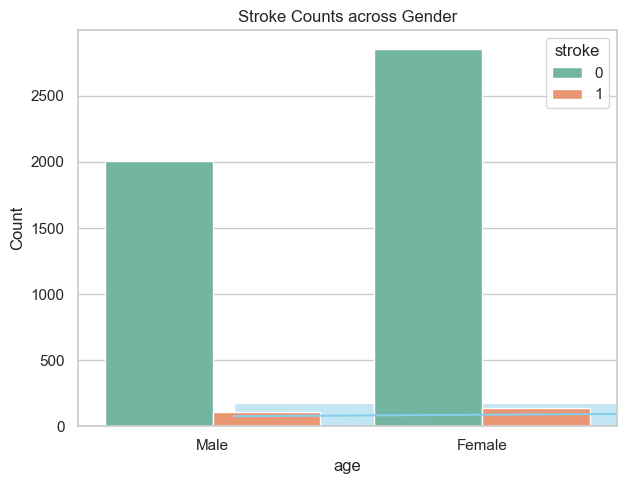

-> Saved: q5_age_stroke_dist.png


In [ ]:
q3_group_smoking_status(df_pandas)
df_pandas = q4_glucose_bmi_ratio(df_pandas)
q6_pivot_table(df_pandas)
df_pandas = q7_age_groups(df_pandas)
df_pandas = q8_bmi_categories(df_pandas)
q5_basic_visualizations(df_pandas)
plt.show()